In [1]:
# Interactive Clustering Visualization Notebook
# - Compare K-Means vs a chosen clustering algorithm (default: DBSCAN)
# - Use ipywidgets sliders to explore parameter effects

import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, DBSCAN
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.preprocessing import StandardScaler

import ipywidgets as widgets
from IPython.display import display, clear_output


In [2]:
def _smiley_dataset(n_samples=600, noise=0.05, random_state=0):
    """Custom 'smiley face' dataset for fun cluster behavior."""
    rng = np.random.default_rng(random_state)

    # Face outline (noisy circle)
    n_face = int(n_samples * 0.55)
    theta = rng.uniform(0, 2*np.pi, size=n_face)
    r = 1.0 + rng.normal(0, noise, size=n_face)
    x_face = r * np.cos(theta)
    y_face = r * np.sin(theta)

    # Eyes (two small blobs)
    n_eyes = int(n_samples * 0.20)
    n_eye_each = n_eyes // 2
    eye_std = 0.07 + noise * 0.25

    eye1 = rng.normal(loc=(-0.35, 0.30), scale=eye_std, size=(n_eye_each, 2))
    eye2 = rng.normal(loc=(+0.35, 0.30), scale=eye_std, size=(n_eye_each, 2))

    # Smile arc (noisy arc)
    n_smile = n_samples - (n_face + 2*n_eye_each)
    t = rng.uniform(np.pi*1.15, np.pi*1.85, size=n_smile)  # lower arc
    r_smile = 0.55 + rng.normal(0, noise*0.6, size=n_smile)
    x_smile = r_smile * np.cos(t)
    y_smile = r_smile * np.sin(t) - 0.05

    X = np.vstack([
        np.column_stack([x_face, y_face]),
        eye1, eye2,
        np.column_stack([x_smile, y_smile])
    ])

    # Light jitter everywhere
    X = X + rng.normal(0, noise * 0.15, size=X.shape)
    return X


def make_dataset(kind="blobs", n_samples=500, noise=0.06, random_state=0,
                 centers=4, cluster_std=0.55, circles_factor=0.5):
    """Return X (n_samples, 2) for visualization."""
    if kind == "blobs":
        X, _ = make_blobs(
            n_samples=n_samples,
            centers=centers,
            cluster_std=cluster_std,
            random_state=random_state
        )
        # Add a touch of noise to make boundaries less perfect
        rng = np.random.default_rng(random_state)
        X = X + rng.normal(0, noise, size=X.shape)
        return X

    if kind == "moons":
        X, _ = make_moons(
            n_samples=n_samples,
            noise=noise,
            random_state=random_state
        )
        return X

    if kind == "circles":
        X, _ = make_circles(
            n_samples=n_samples,
            noise=noise,
            factor=circles_factor,
            random_state=random_state
        )
        return X

    if kind == "nested_circles":
        # same as circles, but default factor a bit smaller to make rings more separated
        X, _ = make_circles(
            n_samples=n_samples,
            noise=noise,
            factor=max(0.15, min(0.85, circles_factor)),
            random_state=random_state
        )
        return X

    if kind == "smiley":
        return _smiley_dataset(n_samples=n_samples, noise=noise, random_state=random_state)

    raise ValueError(f"Unknown dataset kind: {kind}")


In [3]:
def _plot_clusters(title, X, labels, centers=None, noise_label=-1):
    """Scatter plot of X colored by labels; optionally draw centers."""
    plt.figure(figsize=(7, 6))
    unique = np.unique(labels)

    for lab in unique:
        mask = labels == lab
        if lab == noise_label:
            plt.scatter(X[mask, 0], X[mask, 1], marker="x", s=35, alpha=0.9, label="noise");
        else:
            plt.scatter(X[mask, 0], X[mask, 1], s=25, alpha=0.85, label=f"cluster {lab}")

    if centers is not None and len(centers) > 0:
        plt.scatter(centers[:, 0], centers[:, 1], marker="*", s=280, edgecolor="k", linewidths=1.0, label="centers")

    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend(loc="best", fontsize=9)
    plt.tight_layout()
    plt.show()


In [4]:
def run_and_plot(kind="moons", n_samples=500, noise=0.06, random_state=0,
                 centers=4, cluster_std=0.55, circles_factor=0.50,
                 scale=True,
                 kmeans_k=4,
                 dbscan_eps=0.25, dbscan_min_samples=10):
    """Generate dataset, run K-Means and DBSCAN, and plot results."""
    X = make_dataset(
        kind=kind,
        n_samples=n_samples,
        noise=noise,
        random_state=random_state,
        centers=centers,
        cluster_std=cluster_std,
        circles_factor=circles_factor
    )

    X_use = StandardScaler().fit_transform(X) if scale else X

    # --- K-Means ---
    kmeans = KMeans(n_clusters=int(kmeans_k), n_init="auto", random_state=random_state)
    km_labels = kmeans.fit_predict(X_use)

    # centers need to be in the same space as plotted points
    km_centers = kmeans.cluster_centers_
    if scale:
        # For plotting, show scaled space (since X_use is scaled).
        X_plot = X_use
        centers_plot = km_centers
        space_note = "(scaled)"
    else:
        X_plot = X_use
        centers_plot = km_centers
        space_note = "(raw)"

    # --- DBSCAN ---
    db = DBSCAN(eps=float(dbscan_eps), min_samples=int(dbscan_min_samples))
    db_labels = db.fit_predict(X_use)

    clear_output(wait=True)

    # Plot K-Means
    _plot_clusters(
        title=f"K-Means {space_note} | k={int(kmeans_k)}",
        X=X_plot,
        labels=km_labels,
        centers=centers_plot,
        noise_label=None  # K-Means has no noise
    )

    # Plot DBSCAN
    n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
    n_noise = int(np.sum(db_labels == -1))

    _plot_clusters(
        title=f"DBSCAN {space_note} | eps={float(dbscan_eps):.3f}, min_samples={int(dbscan_min_samples)} | clusters={n_clusters}, noise={n_noise}",
        X=X_plot,
        labels=db_labels,
        centers=None,
        noise_label=-1
    )


In [5]:
# Interactive controls
dataset_dd = widgets.Dropdown(
    options=[
        ("Synthetic blobs", "blobs"),
        ("Moons", "moons"),
        ("Circles", "circles"),
        ("Nested circles", "nested_circles"),
        ("Smiley face (custom)", "smiley"),
    ],
    value="moons",
    description="Dataset:",
    style={"description_width": "initial"}
)

n_samples_slider = widgets.IntSlider(value=500, min=100, max=2000, step=50, description="n_samples:", style={"description_width": "initial"})
noise_slider = widgets.FloatSlider(value=0.06, min=0.0, max=0.35, step=0.01, description="noise:", readout_format=".2f", style={"description_width": "initial"})
seed_slider = widgets.IntSlider(value=0, min=0, max=200, step=1, description="random_state:", style={"description_width": "initial"})

# Blobs-only knobs (safe to show always)
centers_slider = widgets.IntSlider(value=4, min=2, max=10, step=1, description="blobs centers:", style={"description_width": "initial"})
cluster_std_slider = widgets.FloatSlider(value=0.55, min=0.10, max=2.00, step=0.05, description="blobs std:", readout_format=".2f", style={"description_width": "initial"})

# Circles-only knob
circles_factor_slider = widgets.FloatSlider(value=0.50, min=0.05, max=0.95, step=0.05, description="circles factor:", readout_format=".2f", style={"description_width": "initial"})

scale_chk = widgets.Checkbox(value=True, description="Standardize features (recommended)")

# K-Means params
kmeans_k_slider = widgets.IntSlider(value=4, min=2, max=12, step=1, description="K-Means k:", style={"description_width": "initial"})

# DBSCAN params
dbscan_eps_slider = widgets.FloatSlider(value=0.25, min=0.01, max=2.00, step=0.01, description="DBSCAN eps:", readout_format=".2f", style={"description_width": "initial"})
dbscan_min_samples_slider = widgets.IntSlider(value=10, min=2, max=80, step=1, description="DBSCAN min_samples:", style={"description_width": "initial"})

controls_left = widgets.VBox([dataset_dd, n_samples_slider, noise_slider, seed_slider, scale_chk])
controls_mid  = widgets.VBox([kmeans_k_slider, dbscan_eps_slider, dbscan_min_samples_slider])
controls_right = widgets.VBox([centers_slider, cluster_std_slider, circles_factor_slider])

controls = widgets.HBox([controls_left, controls_mid, controls_right])

out = widgets.interactive_output(
    run_and_plot,
    {
        "kind": dataset_dd,
        "n_samples": n_samples_slider,
        "noise": noise_slider,
        "random_state": seed_slider,
        "centers": centers_slider,
        "cluster_std": cluster_std_slider,
        "circles_factor": circles_factor_slider,
        "scale": scale_chk,
        "kmeans_k": kmeans_k_slider,
        "dbscan_eps": dbscan_eps_slider,
        "dbscan_min_samples": dbscan_min_samples_slider
    }
)

display(controls, out)


Output()

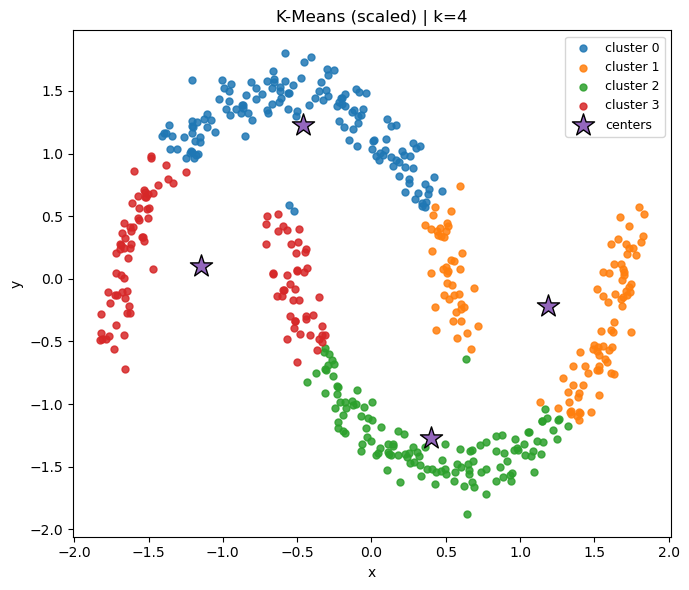

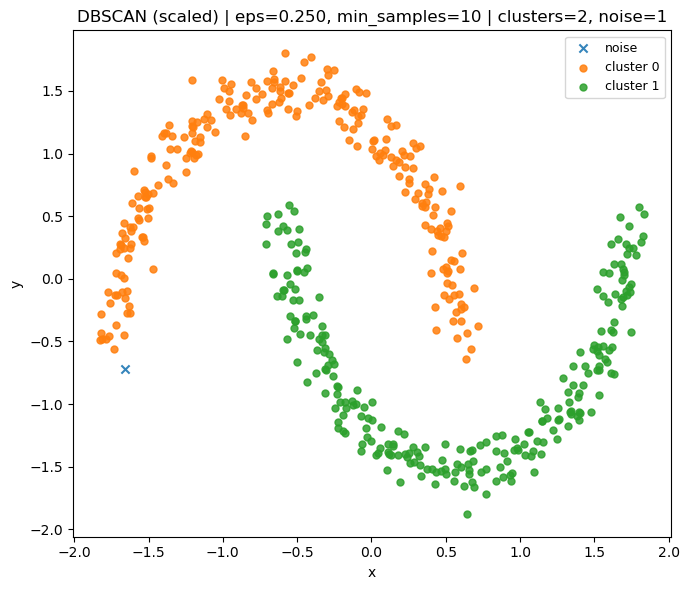

In [6]:
run_and_plot()


### What happens when algorithm parameters change?
Changing parameters like k in K-Means or eps and min_samples in DBSCAN directly changes how points are grouped based on distance and density. Small adjustments can cause clusters to merge, split, or turn into noise depending on how strict the grouping criteria become.

### Does clustering improve or worsen with certain parameter choices?
certain parameters, like having DBSCAN eps be too low or too high, make the algorithm mark datapoints as outliers or all as one group. and with K means, choosing a k that is too small merges distinct clusters together, while a k that is too large splits natural groups into unnecessary smaller clusters.

### In what situations would this algorithm fail?
DBSCAN struggles when clusters have varying densities or when eps is too much or little. K-Means fails on non-spherical or curved shapes, works very well with blobs.

### How do results compare to K-Means on the same dataset?
K-Means performs well on compact, spherical clusters like blobs but struggles with complex shapes. DBSCAN handles arbitrary shapes and noise better but requires parameter tuning to avoid over or under clustering